In [76]:
import pandas as pd

In [77]:
df = pd.read_csv('./results/cleaned_shipment_classification_dataset.csv')

In [78]:
# columns_to_drop = ['receipt_date', 'shipment_delay_days', 'shipment_terms','vessel__voyage',]
# df = df.drop(columns=columns_to_drop)

In [79]:
df.columns

Index(['quantity_in', 'batch_created_time', 'bill_date', 'b.coo',
       'shipping_port', 'shipped_date', 'due_date', 'eta', 'b.payment_terms',
       'scac', 'tariff_amount', 'sku', 'brand', 'manufacturer',
       'shipment_classified'],
      dtype='object')

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          822 non-null    float64
 1   batch_created_time   822 non-null    object 
 2   bill_date            822 non-null    object 
 3   b.coo                822 non-null    object 
 4   shipping_port        822 non-null    object 
 5   shipped_date         822 non-null    object 
 6   due_date             822 non-null    object 
 7   eta                  822 non-null    object 
 8   b.payment_terms      822 non-null    int64  
 9   scac                 822 non-null    object 
 10  tariff_amount        822 non-null    float64
 11  sku                  822 non-null    int64  
 12  brand                822 non-null    object 
 13  manufacturer         822 non-null    object 
 14  shipment_classified  822 non-null    object 
dtypes: float64(2), int64(2), object(11)
memo

In [81]:
df.head(n=5)

,quantity_in,batch_created_time,bill_date,b.coo,shipping_port,shipped_date,due_date,eta,b.payment_terms,scac,tariff_amount,sku,brand,manufacturer,shipment_classified
0,35000.0,2025-10-17 18:36:28+00:00,2025-10-17,ECUADOR,Guayaquil,2025-09-26,2025-10-17,2025-10-10,0,SMLU,18847.50,855,GREAT VALUE,VANNAMEI,on_time
1,4452.0,2025-10-15 17:27:39+00:00,2025-10-15,VIETNAM,Vung Tau Port,2025-08-23,2025-11-14,2025-10-11,30,MAEU,27615.34,1994,MARKET SIDE,AHI TUNA,on_time
2,29892.0,2025-10-15 17:27:39+00:00,2025-10-15,VIETNAM,Vung Tau Port,2025-08-23,2025-11-14,2025-10-11,30,MAEU,27615.34,1994,MARKET SIDE,AHI TUNA,on_time
3,34020.0,2025-10-14 15:26:39+00:00,2025-10-14,INDIA,Ennore,2025-08-05,2025-10-14,2025-10-10,0,MAEU,54947.00,857,GREAT VALUE,VANNAMEI,on_time
4,35280.0,2025-10-13 16:57:47+00:00,2025-10-13,INDONESIA,TG. PRIOK,2025-08-14,2025-10-13,2025-10-08,0,EGLV,21660.57,865,GREAT VALUE,VANNAMEI,on_time


In [82]:
# df['inventory'].value_counts()

## Distribution of shipment classification -> Imbalanced Class

<Axes: title={'center': 'Shipment Status Distribution'}, xlabel='shipment_classified'>

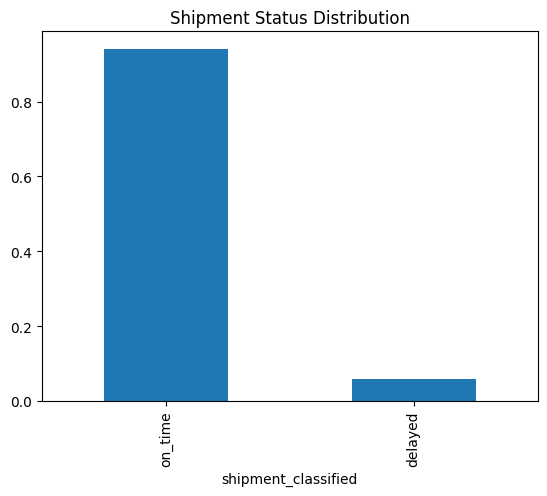

In [83]:
# Distribution of shipment classification
df['shipment_classified'].value_counts(normalize=True).plot(kind='bar', title='Shipment Status Distribution')

In [84]:
# df['fda_status'].value_counts().plot(kind='bar', title='FDA Status Distribution')

In [85]:
# df['coo'].value_counts().plot(kind='bar', title='COO Distribution')

In [86]:
# df['inventory'].value_counts().plot(kind='bar', title='Inventory Distribution')

In [87]:
# df['payment_terms'].value_counts().plot(kind='bar', title='FDA Status Distribution')

In [88]:
# df['discount'].hist(grid=False, bins=30)

In [89]:
# seems need to remove sku 
# need to do feature engineering

In [90]:
# df['vessel__voyage'].value_counts().plot(kind='bar', title='Vessel Voyage Distribution')

In [91]:
# df['consignee'].value_counts().plot(kind='bar', title='Consignee Distribution')

## Most Used to Least Used Custom Brokers

In [92]:
# df['customs_broker'].value_counts().plot(kind='bar')

## Distribution of the Amount of Quantity that is brought in the shipment

<Axes: xlabel='quantity_in', ylabel='Count'>

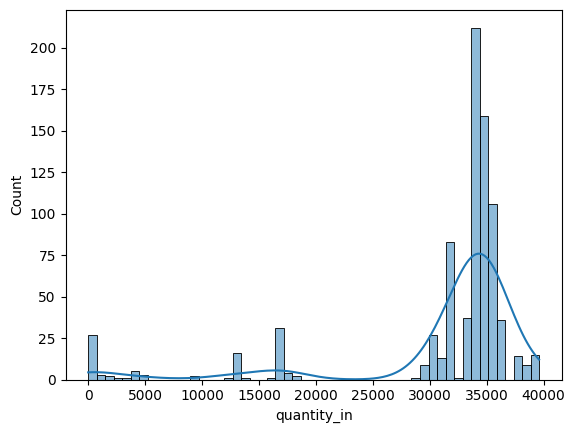

In [93]:
import seaborn as sns
sns.histplot(df['quantity_in'], kde=True)

## For both category the spread of amount of quantity is similar

<Axes: xlabel='shipment_classified', ylabel='quantity_in'>

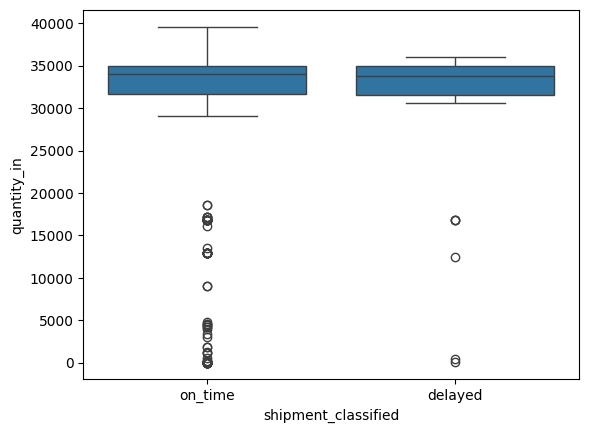

In [94]:
sns.boxplot(x='shipment_classified', y='quantity_in', data=df)

In [95]:
# sns.boxplot(x='shipment_classified', y='yield_percentage', data=df) # need to remove this

<Axes: xlabel='shipment_classified', ylabel='gap_bill_to_ship'>

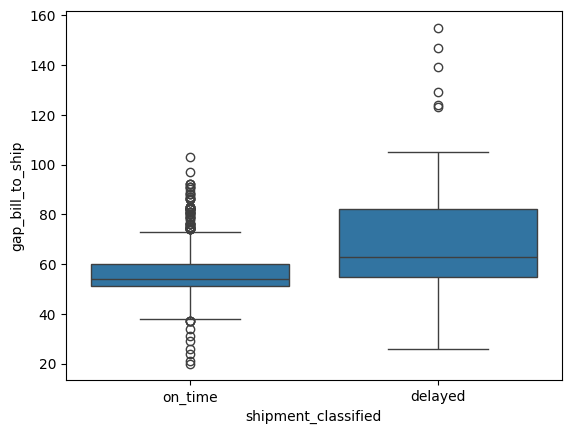

In [96]:
# df["gap_between_bill_and_shipment"] = (
#     df["bill_date"] - df["shipped_date"]
# ).dt.days
df['gap_bill_to_ship'] = (pd.to_datetime(df['bill_date']) - pd.to_datetime(df['shipped_date'])).dt.days
sns.boxplot(x='shipment_classified', y='gap_bill_to_ship', data=df)

<Axes: xlabel='shipment_classified', ylabel='gap_ship_to_due'>

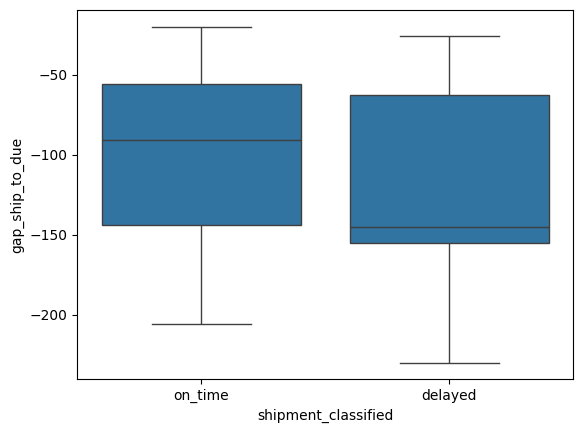

In [97]:
df['gap_ship_to_due'] = (pd.to_datetime(df['shipped_date']) - pd.to_datetime(df['due_date'])).dt.days
sns.boxplot(x='shipment_classified', y='gap_ship_to_due', data=df)

<Axes: xlabel='shipment_classified', ylabel='count'>

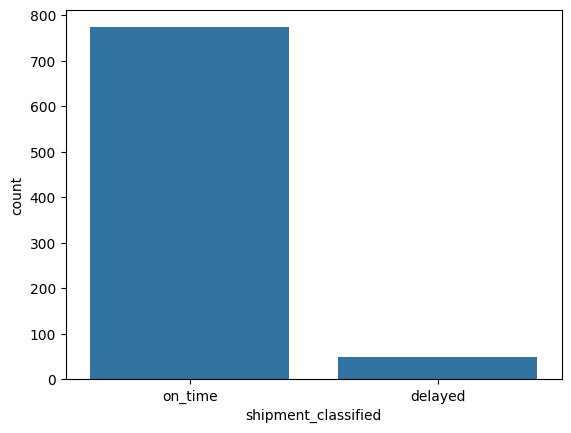

In [98]:
sns.countplot(x='shipment_classified', data=df)

In [99]:
# sns.countplot(x='seal', hue='shipment_classified', data=df)

In [100]:
# sns.countplot(x='customs_broker', hue='shipment_classified', data=df)

In [101]:
df['bill_month'] = pd.to_datetime(df['bill_date']).dt.month
df['bill_weekday'] = pd.to_datetime(df['bill_date']).dt.day_name()

<Axes: xlabel='bill_weekday', ylabel='count'>

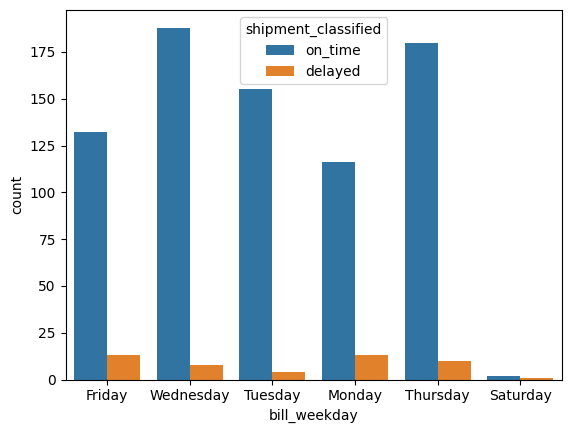

In [102]:
sns.countplot(x='bill_weekday', hue='shipment_classified', data=df)

<Axes: xlabel='bill_month', ylabel='count'>

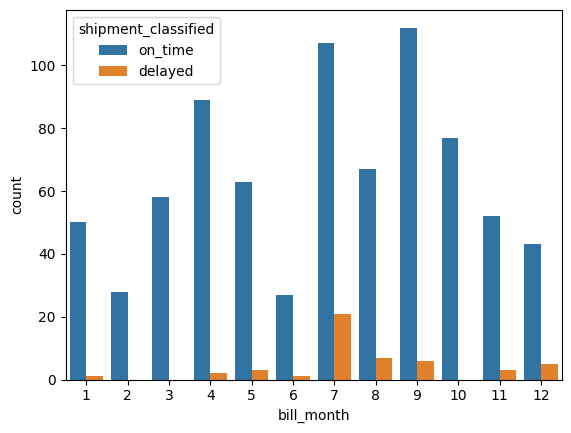

In [103]:
sns.countplot(x='bill_month', hue='shipment_classified', data=df)

<Axes: xlabel='b.coo', ylabel='count'>

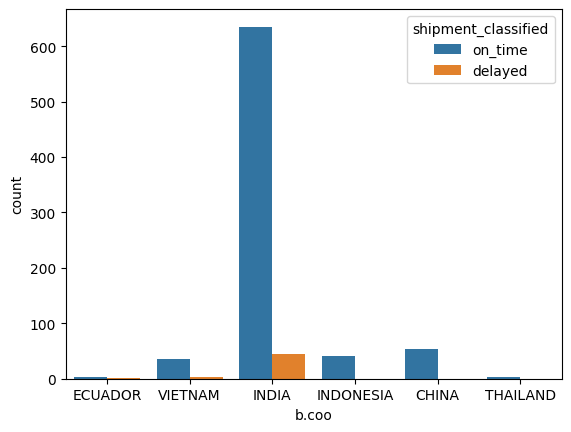

In [104]:
sns.countplot(x='b.coo', hue='shipment_classified', data=df)

In [105]:
df.columns

Index(['quantity_in', 'batch_created_time', 'bill_date', 'b.coo',
       'shipping_port', 'shipped_date', 'due_date', 'eta', 'b.payment_terms',
       'scac', 'tariff_amount', 'sku', 'brand', 'manufacturer',
       'shipment_classified', 'gap_bill_to_ship', 'gap_ship_to_due',
       'bill_month', 'bill_weekday'],
      dtype='object')

In [106]:
import numpy as np
df.select_dtypes(include=[np.number]).corr()

,quantity_in,b.payment_terms,tariff_amount,sku,gap_bill_to_ship,gap_ship_to_due,bill_month
quantity_in,1.000000,-0.224927,-0.028229,-0.151826,0.024791,0.222284,-0.023334
b.payment_terms,-0.224927,1.000000,-0.206762,-0.075484,-0.094581,-0.956898,-0.119734
tariff_amount,-0.028229,-0.206762,1.000000,0.242594,-0.073608,0.227369,0.153921
sku,-0.151826,-0.075484,0.242594,1.000000,-0.242989,0.144296,-0.015486
gap_bill_to_ship,0.024791,-0.094581,-0.073608,-0.242989,1.000000,-0.178605,0.074248
gap_ship_to_due,0.222284,-0.956898,0.227369,0.144296,-0.178605,1.000000,0.102393
bill_month,-0.023334,-0.119734,0.153921,-0.015486,0.074248,0.102393,1.000000


In [107]:
# df['bill_present_status'].value_counts().plot(kind='bar', title='Bill Status Distribution')

In [108]:
# df['bill_status'].value_counts().plot(kind='bar', title='Bill Status Distribution')

<Axes: title={'center': 'Payment Terms Distribution'}, xlabel='b.payment_terms'>

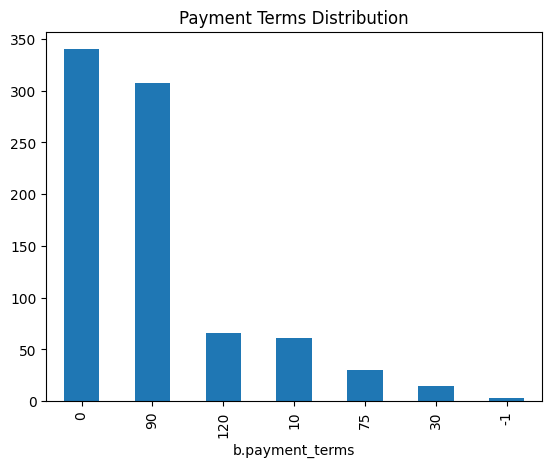

In [109]:
df['b.payment_terms'].value_counts().plot(kind='bar', title='Payment Terms Distribution')

<Axes: title={'center': 'Container Distribution'}, xlabel='scac'>

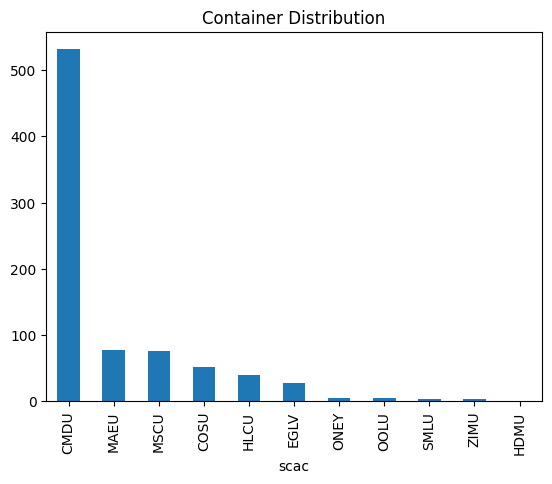

In [110]:
df['scac'].value_counts().plot(kind='bar', title='Container Distribution')

<Axes: title={'center': 'SKU Distribution'}, xlabel='sku'>

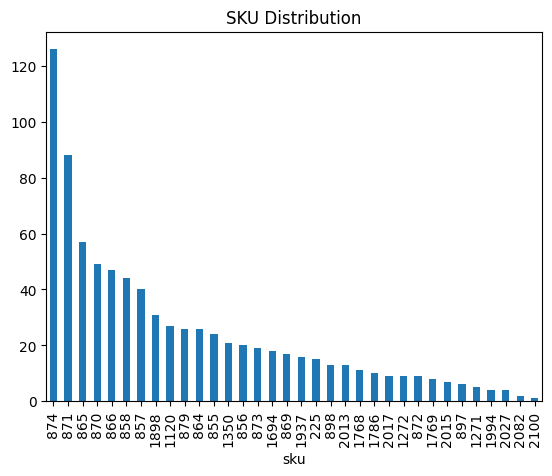

In [111]:
df['sku'].value_counts().plot(kind='bar', title='SKU Distribution')

<Axes: title={'center': 'Brand Distribution'}, xlabel='brand'>

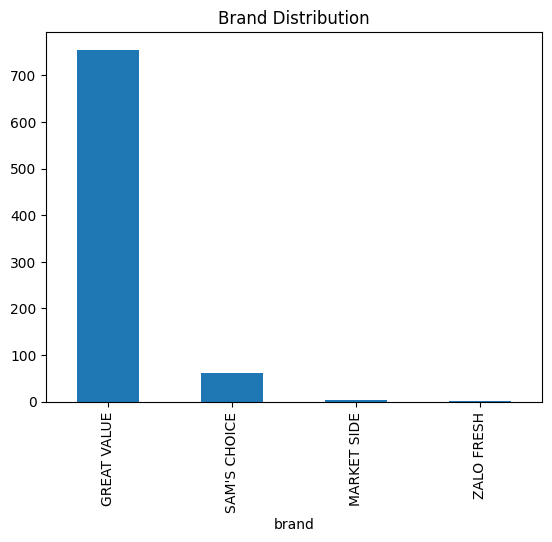

In [112]:
df['brand'].value_counts().plot(kind='bar', title='Brand Distribution')

<Axes: title={'center': 'Manufacturer Distribution'}, xlabel='manufacturer'>

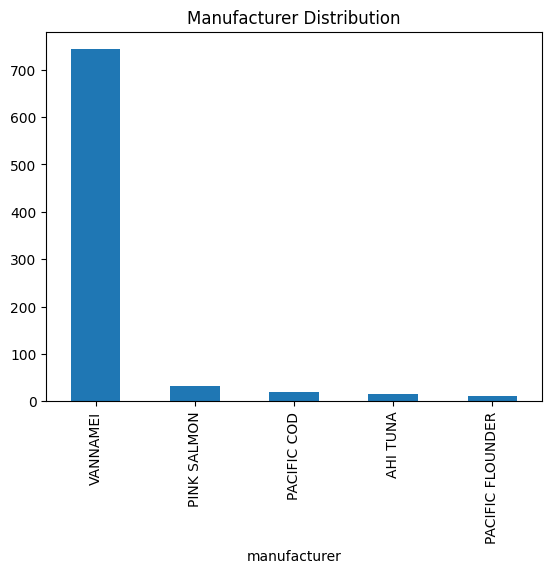

In [113]:
df['manufacturer'].value_counts().plot(kind='bar', title='Manufacturer Distribution')

<Axes: xlabel='manufacturer', ylabel='count'>

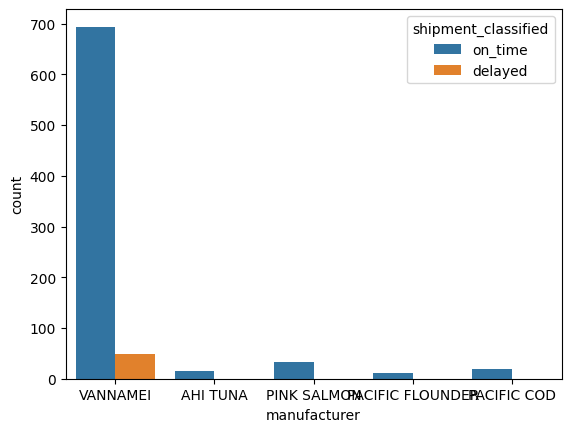

In [114]:
sns.countplot(x='manufacturer', hue='shipment_classified', data=df)

<Axes: xlabel='brand', ylabel='count'>

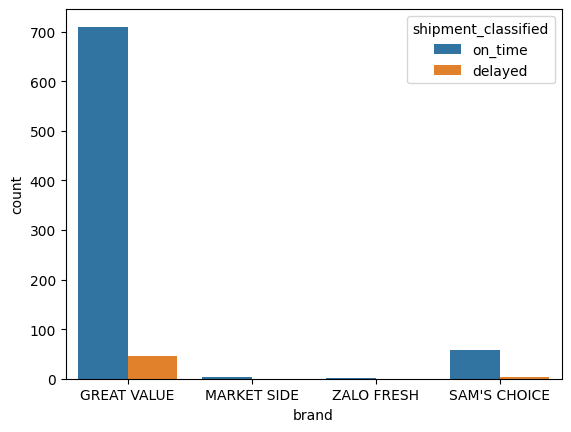

In [115]:
sns.countplot(x='brand', hue='shipment_classified', data=df)

In [116]:
# df['fda_status'].value_counts() 

In [117]:
# df['bill_item_size'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [118]:
# df['bill_type'].value_counts().plot(kind='bar', title='Bill Type Distribution')

In [119]:
# df['bill_status'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [120]:
# df['bill_type'].value_counts().plot(kind='bar', title='Bill Item Size Distribution')

In [121]:
# df['status'].value_counts()

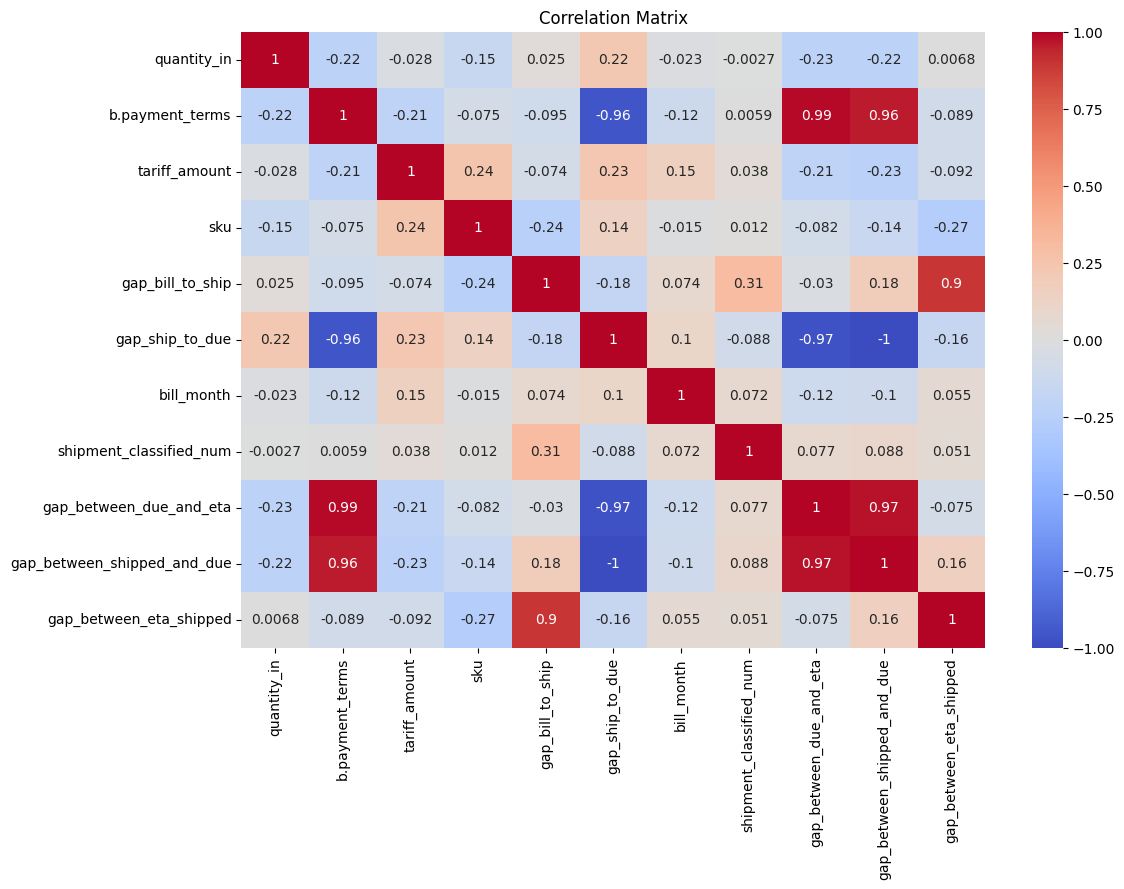

shipment_classified_num        1.000000
gap_bill_to_ship               0.305223
gap_between_shipped_and_due    0.087909
gap_between_due_and_eta        0.076878
bill_month                     0.072288
gap_between_eta_shipped        0.050859
tariff_amount                  0.037527
sku                            0.012353
b.payment_terms                0.005916
quantity_in                   -0.002722
gap_ship_to_due               -0.087909
Name: shipment_classified_num, dtype: float64


In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your DataFrame; replace with pd.read_csv('your_file.csv')
# df = pd.read_csv('your_file.csv')

# Convert inventory to numeric
# df['inventory_num'] = pd.to_numeric(df['inventory'], errors='coerce')
# df.drop('inventory', axis=1, inplace=True)  # Drop original if needed

# One-hot encode categoricals: fda_status and coo
# df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded = df.copy()

# Binary encode target: Map shipment_classified to 0/1 ('delayed'=1, 'on_time'=0)
df_encoded["shipment_classified_num"] = df_encoded["shipment_classified"].map(
    {"delayed": 1, "on_time": 0}
)
df_encoded.drop("shipment_classified", axis=1, inplace=True)

date_columns = [
    "eta",
    "due_date",
    # "bill_date",
    "shipped_date"
]  # 'receipt_date' will only be placed after shipment is received
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors="coerce")

# --- 5️⃣ Create derived time features ---
# for col in date_columns:
#     df_encoded[f"{col}_year"] = df_encoded[f"{col}"].dt.year
#     df_encoded[f"{col}_month"] = df_encoded[f"{col}"].dt.month
#     df[f"{col}_day"] = df_encoded[col].dt.day
#     df_encoded[f"{col}_weekday"] = df_encoded[f"{col}"].dt.weekday

# df_encoded["due_gap"] = (
#     pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
# ).dt.days
df_encoded["gap_between_due_and_eta"] = (
    df_encoded["due_date"] - df_encoded["eta"]
).dt.days
df_encoded["gap_between_shipped_and_due"] = (
    df_encoded["due_date"] - df_encoded["shipped_date"]
).dt.days


# df_encoded["gap_between_bill_and_shipment"] = (
#     df_encoded["bill_date"] - df_encoded["shipped_date"]
# ).dt.days
df_encoded["gap_between_eta_shipped"] = (
    df_encoded["eta"] - df_encoded["shipped_date"]
).dt.days
# df_encoded["gap_between_eta_bill"] = (
#     df_encoded["eta"] - df_encoded["bill_date"]
# ).dt.days

# df_encoded["due_gap"] = (
#     pd.to_datetime(df_encoded["due_date"]) - pd.to_datetime(df_encoded["bill_date"])
# ).dt.days
# df_encoded["responsiveness"] = (
#     df_encoded["bill_date"] - df_encoded["shipped_date"]
# ).dt.days
df_encoded.drop(date_columns, axis=1, inplace=True)

# Select numerical columns for correlation
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numerical_cols].corr()

# Visualize correlation heatmap (optional)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

# Print correlations with target
print(corr_matrix["shipment_classified_num"].sort_values(ascending=False))

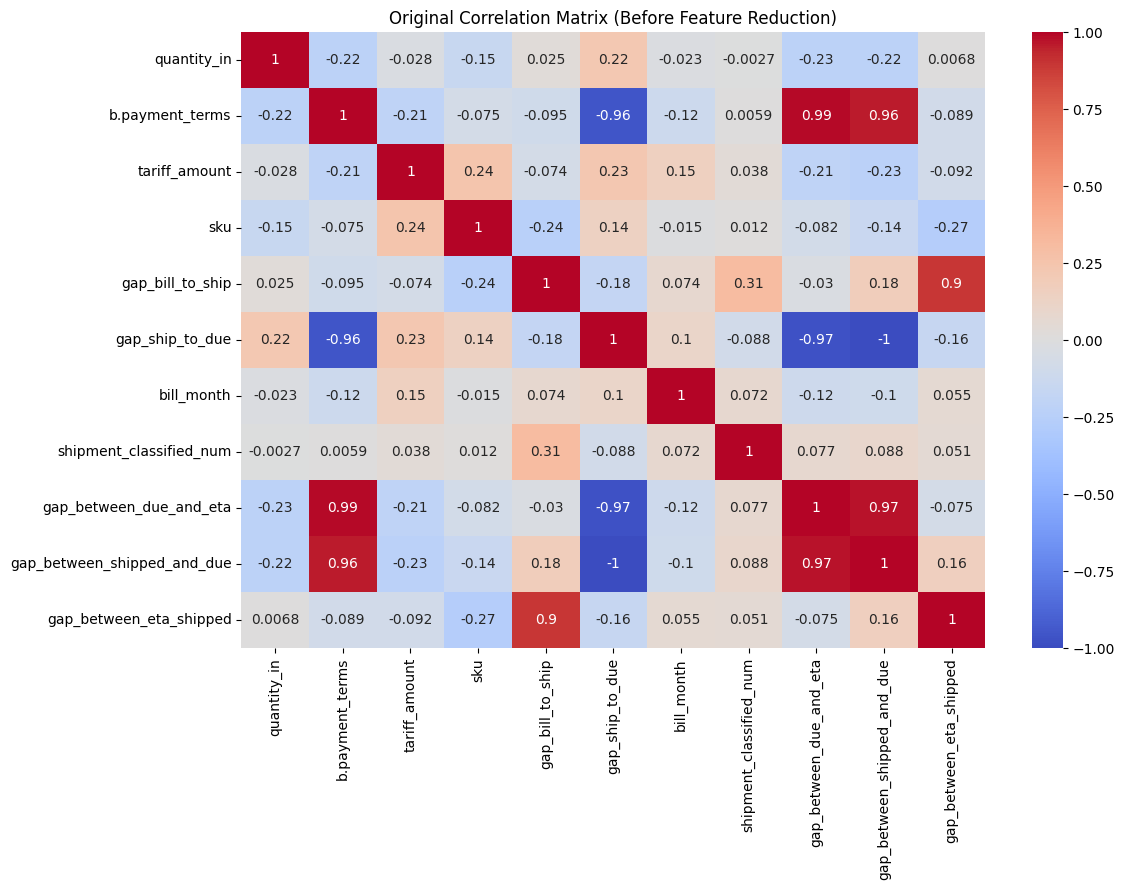


Highly correlated features (>|0.9|) to drop:
['gap_ship_to_due', 'gap_between_due_and_eta', 'gap_between_shipped_and_due']

Correlation with target variable (shipment_classified_num):
shipment_classified_num    1.000000
gap_bill_to_ship           0.305223
bill_month                 0.072288
gap_between_eta_shipped    0.050859
tariff_amount              0.037527
sku                        0.012353
b.payment_terms            0.005916
quantity_in               -0.002722
Name: shipment_classified_num, dtype: float64

Final number of features used: 8


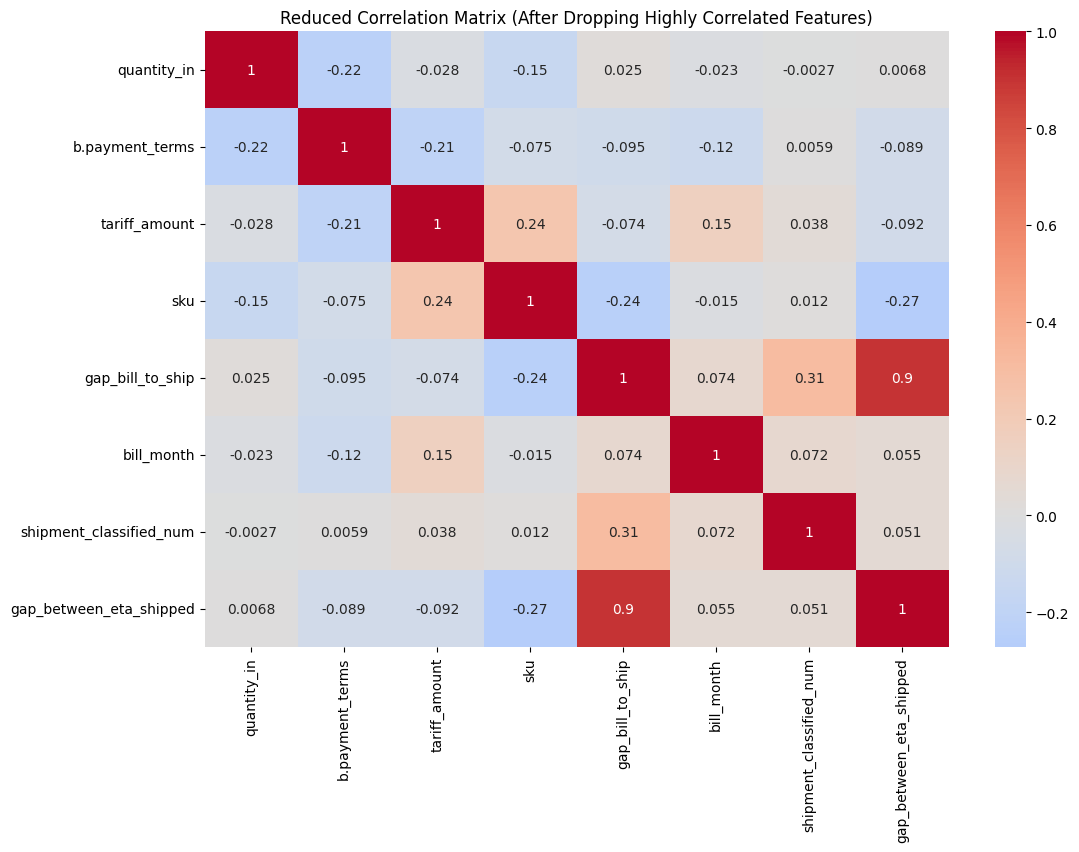

In [123]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assume df is your DataFrame
# df = pd.read_csv('your_file.csv')

df_encoded = df.copy()

# --- 1️⃣ Encode the target ---
df_encoded["shipment_classified_num"] = df_encoded["shipment_classified"].map(
    {"delayed": 1, "on_time": 0}
)
df_encoded.drop("shipment_classified", axis=1, inplace=True)

# --- 2️⃣ Convert date columns ---
date_columns = ["eta", "due_date", "shipped_date", "bill_date"]
for col in date_columns:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors="coerce")

# --- 3️⃣ Derived time gap features ---
# df_encoded["due_gap"] = (df_encoded["due_date"] - df_encoded["bill_date"]).dt.days
df_encoded["gap_between_due_and_eta"] = (df_encoded["due_date"] - df_encoded["eta"]).dt.days
df_encoded["gap_between_shipped_and_due"] = (df_encoded["due_date"] - df_encoded["shipped_date"]).dt.days
# df_encoded["gap_between_bill_and_shipment"] = (df_encoded["bill_date"] - df_encoded["shipped_date"]).dt.days
df_encoded["gap_between_eta_shipped"] = (df_encoded["eta"] - df_encoded["shipped_date"]).dt.days
# df_encoded["gap_between_eta_bill"] = (df_encoded["eta"] - df_encoded["bill_date"]).dt.days
# df_encoded["responsiveness"] = (df_encoded["bill_date"] - df_encoded["shipped_date"]).dt.days



# Drop raw date columns (keep only numeric)
df_encoded.drop(date_columns, axis=1, inplace=True)

# --- 4️⃣ Correlation analysis ---
numerical_cols = df_encoded.select_dtypes(include=[np.number]).columns
corr_matrix = df_encoded[numerical_cols].corr()

# Plot original correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Original Correlation Matrix (Before Feature Reduction)")
plt.show()

# --- 5️⃣ Identify and drop highly correlated features ---
def drop_highly_correlated_features(data, threshold=0.9):
    corr_matrix = data.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [
        column for column in upper_triangle.columns if any(upper_triangle[column] > threshold)
    ]
    print(f"\nHighly correlated features (>|{threshold}|) to drop:\n{to_drop}")
    return data.drop(columns=to_drop, errors="ignore")

df_reduced = drop_highly_correlated_features(df_encoded[numerical_cols])

# --- 6️⃣ Correlation with target ---
target_corr = df_reduced.corr()["shipment_classified_num"].sort_values(ascending=False)
print("\nCorrelation with target variable (shipment_classified_num):")
print(target_corr)

print(f"\nFinal number of features used: {len(df_reduced.columns)}")

# --- 7️⃣ Plot correlation heatmap after dropping correlated features ---
plt.figure(figsize=(12, 8))
sns.heatmap(df_reduced.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Reduced Correlation Matrix (After Dropping Highly Correlated Features)")
plt.show()


In [124]:
# df['scac'].value_counts().plot(kind='bar', title='SCAC Distribution')

In [125]:
# df['item_cases'].value_counts()

In [126]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Copy dataframe
df_corr = df.copy()

# Encode categorical columns
le = LabelEncoder()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = le.fit_transform(df_corr[col].astype(str))

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Correlation with target
target_corr = corr_matrix['shipment_classified'].sort_values(ascending=False)

print(target_corr)


shipment_classified    1.000000
bill_weekday           0.105106
gap_ship_to_due        0.087909
scac                   0.020710
shipping_port          0.003090
quantity_in            0.002722
brand                 -0.001816
b.payment_terms       -0.005916
sku                   -0.012353
tariff_amount         -0.037527
shipped_date          -0.044275
b.coo                 -0.045652
eta                   -0.045980
batch_created_time    -0.058315
bill_date             -0.062667
due_date              -0.065906
manufacturer          -0.071881
bill_month            -0.072288
gap_bill_to_ship      -0.305223
Name: shipment_classified, dtype: float64


In [127]:
import numpy as np
import scipy.stats as ss

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

for col in df.select_dtypes('object').columns:
    if col != 'shipment_classified':
        print(f"{col}: {cramers_v(df[col], df['shipment_classified']):.3f}")


batch_created_time: 0.167
bill_date: 0.595
b.coo: 0.074
shipping_port: 0.000
shipped_date: 0.389
due_date: 0.551
eta: 0.439
scac: 0.000
brand: 0.000
manufacturer: 0.043
bill_weekday: 0.110


## checking the dataset for Logistic regression

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   quantity_in          822 non-null    float64
 1   batch_created_time   822 non-null    object 
 2   bill_date            822 non-null    object 
 3   b.coo                822 non-null    object 
 4   shipping_port        822 non-null    object 
 5   shipped_date         822 non-null    object 
 6   due_date             822 non-null    object 
 7   eta                  822 non-null    object 
 8   b.payment_terms      822 non-null    int64  
 9   scac                 822 non-null    object 
 10  tariff_amount        822 non-null    float64
 11  sku                  822 non-null    int64  
 12  brand                822 non-null    object 
 13  manufacturer         822 non-null    object 
 14  shipment_classified  822 non-null    object 
 15  gap_bill_to_ship     822 non-null    int

In [129]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = df[['quantity_in','tariff_amount','sku','gap_ship_to_due','bill_month']].astype(float)
X = add_constant(X)
vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)
# ,'gap_bill_to_ship', 'b.payment_terms'

           Feature        VIF
0            const  46.670668
1      quantity_in   1.096289
2    tariff_amount   1.132242
3              sku   1.112337
4  gap_ship_to_due   1.145138
5       bill_month   1.035763


In [130]:
df[['quantity_in','tariff_amount','gap_bill_to_ship','gap_ship_to_due']].describe()

,quantity_in,tariff_amount,gap_bill_to_ship,gap_ship_to_due
count,822.000000,822.000000,822.000000,822.000000
mean,31155.010949,3704.344428,57.454988,-105.029197
std,8654.617421,9145.438917,12.931650,47.171975
min,9.000000,0.000000,20.000000,-230.000000
25%,31500.000000,0.000000,51.000000,-144.000000
50%,34020.000000,0.000000,54.000000,-107.500000
75%,35000.000000,0.000000,61.000000,-56.000000
max,39600.000000,85908.000000,155.000000,-20.000000


In [131]:
df['shipment_classified'].value_counts(normalize=True)


shipment_classified
on_time    0.940389
delayed    0.059611
Name: proportion, dtype: float64

## Preparing the Encoded form of the dataset

In [132]:
df = pd.read_csv("./results/cleaned_shipment_classification_dataset.csv")
date_columns = ["eta", "due_date", "bill_date", "shipped_date", "batch_created_time"]
df_encoded = df.copy()
for col in date_columns:
    df_encoded[col] = pd.to_datetime(
        df_encoded[col], errors="raise"
    )


In [133]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   quantity_in          822 non-null    float64            
 1   batch_created_time   822 non-null    datetime64[ns, UTC]
 2   bill_date            822 non-null    datetime64[ns]     
 3   b.coo                822 non-null    object             
 4   shipping_port        822 non-null    object             
 5   shipped_date         822 non-null    datetime64[ns]     
 6   due_date             822 non-null    datetime64[ns]     
 7   eta                  822 non-null    datetime64[ns]     
 8   b.payment_terms      822 non-null    int64              
 9   scac                 822 non-null    object             
 10  tariff_amount        822 non-null    float64            
 11  sku                  822 non-null    int64              
 12  brand                8

In [134]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# --- 1️⃣ Make a copy ---
df_encoded = df.copy()

# --- 2️⃣ Convert datetime columns into numeric time features ---
datetime_cols = ['batch_created_time','bill_date', 'due_date', 'eta', 'shipped_date']

for col in datetime_cols:
    df_encoded[col] = pd.to_datetime(df_encoded[col], errors='raise', utc=True)

gap_eta_shipped = (df_encoded['eta'] - df_encoded['shipped_date']).dt.days
gap_bill_paid_due = (df_encoded['bill_date'] - df_encoded['due_date']).dt.days
gap_batch_created_to_ship = (df_encoded['batch_created_time'] - df_encoded['shipped_date']).dt.days


for col in datetime_cols:
    # df_encoded[f'{col}_year'] = df_encoded[col].dt.year
    df_encoded[f'{col}_month'] = df_encoded[col].dt.month
    # df_encoded[f'{col}_day'] = df_encoded[col].dt.day
    df_encoded[f'{col}_weekday'] = df_encoded[col].dt.weekday
    # df_encoded[f'{col}_dayofyear'] = df_encoded[col].dt.dayofyear

# check if the item was shipped at holiday
df['shipped_date_holiday'] = (df_encoded['shipped_date_weekday'] > 5).astype(int)
    
# Drop original datetime columns (optional, since we’ve extracted their info)
df_encoded.drop(columns=datetime_cols, inplace=True)

# --- 3️⃣ Identify categorical columns ---
cat_cols = df_encoded.select_dtypes(include=['object']).columns

# --- 4️⃣ Encode categorical variables ---
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le  # store encoders for inverse transform if needed

# --- 5️⃣ Check final dataset ---
print("✅ Encoding complete!")


✅ Encoding complete!


In [135]:
print(df_encoded.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   quantity_in                 822 non-null    float64
 1   b.coo                       822 non-null    int64  
 2   shipping_port               822 non-null    int64  
 3   b.payment_terms             822 non-null    int64  
 4   scac                        822 non-null    int64  
 5   tariff_amount               822 non-null    float64
 6   sku                         822 non-null    int64  
 7   brand                       822 non-null    int64  
 8   manufacturer                822 non-null    int64  
 9   shipment_classified         822 non-null    int64  
 10  batch_created_time_month    822 non-null    int32  
 11  batch_created_time_weekday  822 non-null    int32  
 12  bill_date_month             822 non-null    int32  
 13  bill_date_weekday           822 non

In [136]:
print(df_encoded.head())

   quantity_in  b.coo  shipping_port  b.payment_terms  scac  tariff_amount  \
0      35000.0      1              6                0     9       18847.50   
1       4452.0      5             15               30     5       27615.34   
2      29892.0      5             15               30     5       27615.34   
3      34020.0      2              4                0     5       54947.00   
4      35280.0      3             12                0     2       21660.57   

    sku  brand  manufacturer  shipment_classified  batch_created_time_month  \
0   855      0             4                    1                        10   
1  1994      1             0                    1                        10   
2  1994      1             0                    1                        10   
3   857      0             4                    1                        10   
4   865      0             4                    1                        10   

   batch_created_time_weekday  bill_date_month  bill_dat

In [137]:
df_encoded.to_csv('./results/encoded_shipment_classification_dataset.csv', index=False)

<Axes: >

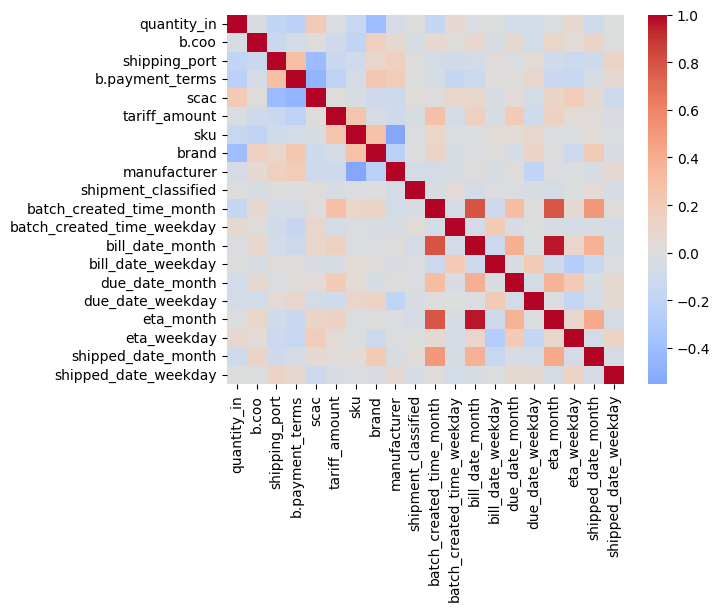

In [138]:
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm", center=0)